# CryoSleep is the strongest single column

Split the 8693 fates by the cryosleep flag.

$$
\begin{aligned}
\text{True: } 2483 \text{ transported, } 554 \text{ stayed, } 2483 + 554 &= 3037 \\
\text{False: } 1789 \text{ transported, } 3650 \text{ stayed, } 1789 + 3650 &= 5439 \\
\text{blank: } 106 \text{ transported, } 111 \text{ stayed, } 106 + 111 &= 217
\end{aligned}
$$

The majority inside each cell is: transported, stayed, stayed. The rule that follows those three majorities is:

1. If `CryoSleep` is `True`, predict transported.
2. Otherwise predict stayed.

Its correct count is the majority piece of each row:

$$
2483 + 3650 + 111 = 6244.
$$

So the cryosleep rule is right on 6244 of 8693 passengers. Against the constant prediction of 4378, the gain is

$$
6244 - 4378 = 1866.
$$

On the six named rows the rule says: Maham stayed, Juanna stayed, Altark stayed, Solam stayed, Candra was transported, Nelly was transported. Maham, the Susents, and Candra match the known fates. Juanna was transported, so the rule is wrong on her. Nelly's fate is unknown. The sample file says she stayed.


In [2]:
# Locate the contest tables beside this notebook, or under the course root.
from pathlib import Path
import csv

def manifest_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "14-Spaceship Titanic" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "sample_submission.csv").exists():
            return direct
    raise FileNotFoundError(name)

def read_manifest(name):
    with manifest_path(name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

train = read_manifest("train.csv")
test = read_manifest("test.csv")
submission = read_manifest("sample_submission.csv")
print(len(train), len(test), len(submission))
print(train[0]["PassengerId"], train[0]["Name"])


8693 4277 4277
0001_01 Maham Ofracculy


In [3]:
# Recount the three cryosleep cells and the majority rule.
from fractions import Fraction
cells = {"True": [0, 0], "False": [0, 0], "": [0, 0]}
for row in train:
    cells[row["CryoSleep"]][row["Transported"] == "True"] += 1
for flag, (stayed, transported) in cells.items():
    print(repr(flag), transported, stayed, transported + stayed)
assert cells["True"] == [554, 2483]
assert cells["False"] == [3650, 1789]
assert cells[""] == [111, 106]
correct = 2483 + 3650 + 111
print("correct", correct, Fraction(correct, 8693))
assert correct == 6244
assert correct - 4378 == 1866

def cryo_rule(row):
    return row["CryoSleep"] == "True"

by_id = {row["PassengerId"]: row for row in train}
assert cryo_rule(by_id["0001_01"]) is False
assert cryo_rule(by_id["0002_01"]) is False
assert cryo_rule(by_id["0006_02"]) is True
assert cryo_rule(test[0]) is True
scored = sum(cryo_rule(row) == (row["Transported"] == "True") for row in train)
assert scored == 6244


'True' 2483 554 3037
'False' 1789 3650 5439
'' 106 111 217
correct 6244 6244/8693


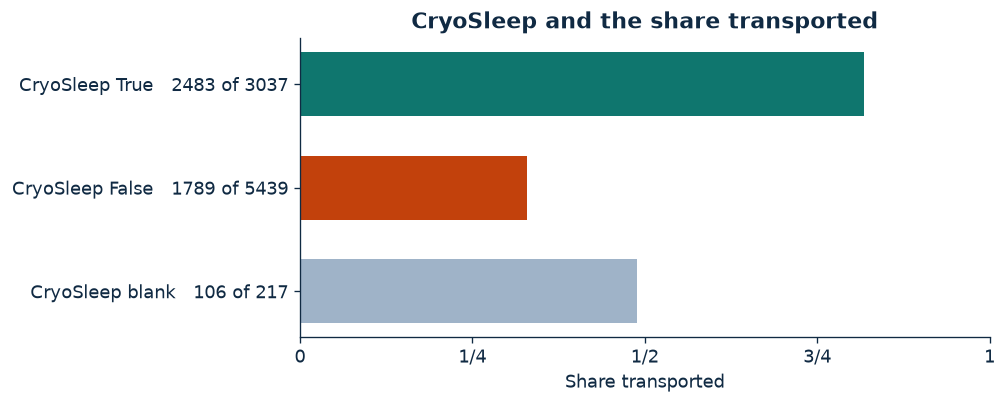

In [4]:
# Draw the three shares from zero, with the count in the label.
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
shares = [
    ("CryoSleep True", 2483, 3037, "#0f766e"),
    ("CryoSleep False", 1789, 5439, "#c2410c"),
    ("CryoSleep blank", 106, 217, "#9fb3c8"),
]
figure, axis = plt.subplots(figsize=(8.6, 3.5))
positions = [2, 1, 0]
axis.barh(
    positions,
    [transported / total for _, transported, total, _ in shares],
    color=[color for *_, color in shares],
    height=0.62,
)
axis.set_yticks(
    positions,
    [f"{name}   {transported} of {total}" for name, transported, total, _ in shares],
)
axis.set_xlim(0, 1)
axis.set_xticks([0, 0.25, 0.5, 0.75, 1])
axis.set_xticklabels(["0", "1/4", "1/2", "3/4", "1"])
axis.set_xlabel("Share transported")
axis.set_title("CryoSleep and the share transported")
figure.tight_layout()


## Pitfall

The blank cell is only five passengers away from a tie: 111 stayed and 106 were transported. The rule still has to answer, and it answers "stayed." That choice is the majority. It is a thin majority.

Candra's empty `VRDeck` does not change step 1. The rule reads `CryoSleep`, which on her row is `True`.

## Summary

One column, three cells, 6244 correct fates. Cryosleep passengers were transported on 2483 of 3037 rows. Awake passengers were transported on 1789 of 5439 rows.
